Image: pavan-1.jpeg | Total faces detected: 1


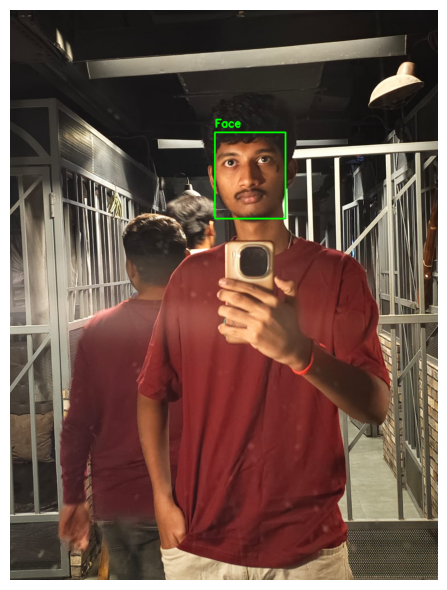

Image: pavan-2.jpeg | Total faces detected: 1


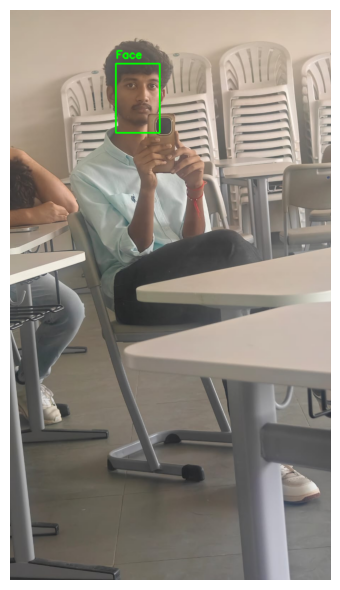

Image: pnithin.jpeg | Total faces detected: 1


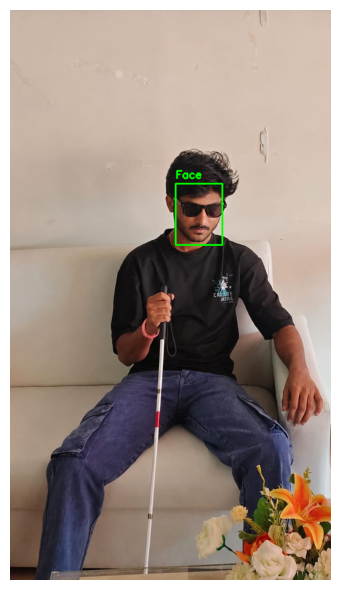

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import urllib.request
import ssl

ssl_context = ssl.SSLContext(ssl.PROTOCOL_TLS_CLIENT)
ssl_context.check_hostname = False
ssl_context.verify_mode = ssl.CERT_NONE

opener = urllib.request.build_opener(urllib.request.HTTPSHandler(context=ssl_context))
urllib.request.install_opener(opener)

proto_url = "https://raw.githubusercontent.com/opencv/opencv/master/samples/dnn/face_detector/deploy.prototxt"
model_url = "https://raw.githubusercontent.com/opencv/opencv_3rdparty/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel"

if not os.path.exists("deploy.prototxt"):
    print("Downloading configuration file...")
    urllib.request.urlretrieve(proto_url, "deploy.prototxt")

if not os.path.exists("res10_300x300_ssd_iter_140000.caffemodel"):
    print("Downloading model weights (~10MB)...")
    urllib.request.urlretrieve(model_url, "res10_300x300_ssd_iter_140000.caffemodel")

net = cv2.dnn.readNetFromCaffe("deploy.prototxt", "res10_300x300_ssd_iter_140000.caffemodel")

DATASET_PATH = "trained_data"
test_filenames = ["pavan-1.jpeg", "pavan-2.jpeg", "pnithin.jpeg"]

for test_filename in test_filenames:
    image_path = os.path.join(DATASET_PATH, test_filename)
    img = cv2.imread(image_path)
    
    if img is None:
        continue
        
    h, w = img.shape[:2]
    blob = cv2.dnn.blobFromImage(cv2.resize(img, (300, 300)), 1.0, (300, 300), (104.0, 177.0, 123.0))
    net.setInput(blob)
    detections = net.forward()
    
    face_count = 0
    
    for i in range(0, detections.shape[2]):
        confidence = detections[0, 0, i, 2]
        
        if confidence > 0.5:
            face_count += 1
            box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
            (startX, startY, endX, endY) = box.astype("int")
            startX, startY = max(0, startX), max(0, startY)
            endX, endY = min(w, endX), min(h, endY)
            
            cv2.rectangle(img, (startX, startY), (endX, endY), (0, 255, 0), 4)
            cv2.putText(img, "Face", (startX, startY - 15), cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 3)
            
    print(f"Image: {test_filename} | Total faces detected: {face_count}")
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(8, 6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.tight_layout()
    plt.show()